## Day 5 — Full EDA Project

In [5]:
import pandas as pd
import numpy as np

# World Cup matches dataset — built inline
data = {
    'Year': [1930,1930,1930,1934,1934,1938,1938,1950,1950,1954,1954,1958,1958,
             1962,1962,1966,1966,1970,1970,1974,1974,1978,1978,1982,1982,1986,
             1986,1990,1990,1994,1994,1998,1998,2002,2002,2006,2006,2010,2010,2014,2014],
    'Home Team': ['France','USA','Argentina','Germany','Austria','Hungary','Italy',
                  'Brazil','Uruguay','Germany','Hungary','France','Brazil','Brazil',
                  'Chile','England','Germany','Brazil','Italy','Netherlands','Germany',
                  'Argentina','Netherlands','Italy','Brazil','Argentina','France',
                  'Germany','Argentina','Brazil','Italy','France','Brazil','Germany',
                  'Brazil','Germany','Italy','Argentina','Germany','Germany','Brazil'],
    'Away Team': ['Mexico','Belgium','France','Sweden','Hungary','Sweden','Norway',
                  'Mexico','Bolivia','Turkey','South Korea','Paraguay','England',
                  'Mexico','Yugoslavia','Mexico','Argentina','Czechoslovakia','Germany',
                  'Australia','Chile','Hungary','Italy','Cameroon','Argentina','Uruguay',
                  'Canada','Yugoslavia','England','Russia','Bulgaria','Denmark','Morocco',
                  'USA','Belgium','Costa Rica','Ghana','Mexico','Serbia','Argentina','Germany'],
    'Home Goals': [4,3,6,5,3,10,2,4,8,4,8,7,5,4,4,4,3,4,4,4,2,2,2,2,4,2,1,4,1,3,2,3,3,8,2,4,2,3,4,4,1],
    'Away Goals': [1,0,3,2,2,3,1,0,0,1,3,3,0,0,2,1,0,1,1,0,1,0,1,1,1,1,0,1,0,0,1,0,0,0,0,1,0,1,0,0,7],
    'Attendance': [93000,18346,41459,12000,14000,20000,21000,81000,79000,30000,
                   27000,25000,60000,69000,63000,87000,71000,72000,73000,62000,
                   67000,71000,48000,73000,75000,65000,43000,74000,55000,80000,
                   43000,75000,54000,50000,70000,66000,69000,84000,70000,74000,78000]
}

df = pd.DataFrame(data)
print(df.head())
print(df.info())
print(df.shape)

   Year  Home Team Away Team  Home Goals  Away Goals  Attendance
0  1930     France    Mexico           4           1       93000
1  1930        USA   Belgium           3           0       18346
2  1930  Argentina    France           6           3       41459
3  1934    Germany    Sweden           5           2       12000
4  1934    Austria   Hungary           3           2       14000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Year        41 non-null     int64 
 1   Home Team   41 non-null     object
 2   Away Team   41 non-null     object
 3   Home Goals  41 non-null     int64 
 4   Away Goals  41 non-null     int64 
 5   Attendance  41 non-null     int64 
dtypes: int64(4), object(2)
memory usage: 2.1+ KB
None
(41, 6)


In [6]:
print(df.isnull().sum())

Year          0
Home Team     0
Away Team     0
Home Goals    0
Away Goals    0
Attendance    0
dtype: int64


### Q1 : Which 10 countries scored the most total goals?

In [9]:
home_goals = df.groupby('Home Team')['Home Goals'].sum()
away_goals = df.groupby('Away Team')['Away Goals'].sum()

total_goals = home_goals.add(away_goals, fill_value=0).sort_values(ascending=False).head(10)
print(total_goals)

Germany        46.0
Brazil         30.0
Hungary        20.0
France         18.0
Argentina      15.0
Italy          13.0
Uruguay         9.0
Netherlands     6.0
Chile           5.0
Sweden          5.0
dtype: float64


### Q2: How has the average number of goals per match changed over the decades?

In [12]:
df['TotalGoals'] = df['Home Goals'] + df['Away Goals']
df['Decade'] = (df['Year'] // 10)*10

Goals_per_d = df.groupby('Decade')['TotalGoals'].mean()
print(Goals_per_d)

Decade
1930    6.428571
1950    7.166667
1960    4.500000
1970    3.666667
1980    3.000000
1990    3.000000
2000    4.250000
2010    5.000000
Name: TotalGoals, dtype: float64


### Q3: Is there a home advantage? Do teams listed as "Home Team" win more often?

In [17]:
def IsWinner(row):
    if row['Home Goals'] > row['Away Goals']:
        return 'Home'
    elif row['Home Goals'] < row['Away Goals']:
        return 'Away'
    else:
        return 'Draw'

df['Winner'] = df.apply(IsWinner, axis=1)
print(df['Winner'].value_counts())

Winner
Home    40
Away     1
Name: count, dtype: int64


### Q4: Which World Cup year had the highest average attendance?

In [18]:
highest_attendance = df.groupby('Year')['Attendance'].mean().sort_values(ascending=False).head(1)
print(highest_attendance)

Year
1950    80000.0
Name: Attendance, dtype: float64


### Q5: Create one visualisation that tells the most interesting story you found in this dataset.

C:\Users\mohiu\AppData\Local\Temp\ipykernel_18388\1724173020.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_goals.index, y=total_goals.values, palette='Blues_d', ax=axs[0])
C:\Users\mohiu\AppData\Local\Temp\ipykernel_18388\1724173020.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0].legend()
C:\Users\mohiu\AppData\Local\Temp\ipykernel_18388\1724173020.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend()
C:\Users\mohiu\AppData\Local\Temp\ipykernel_18388\1724173020.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists who

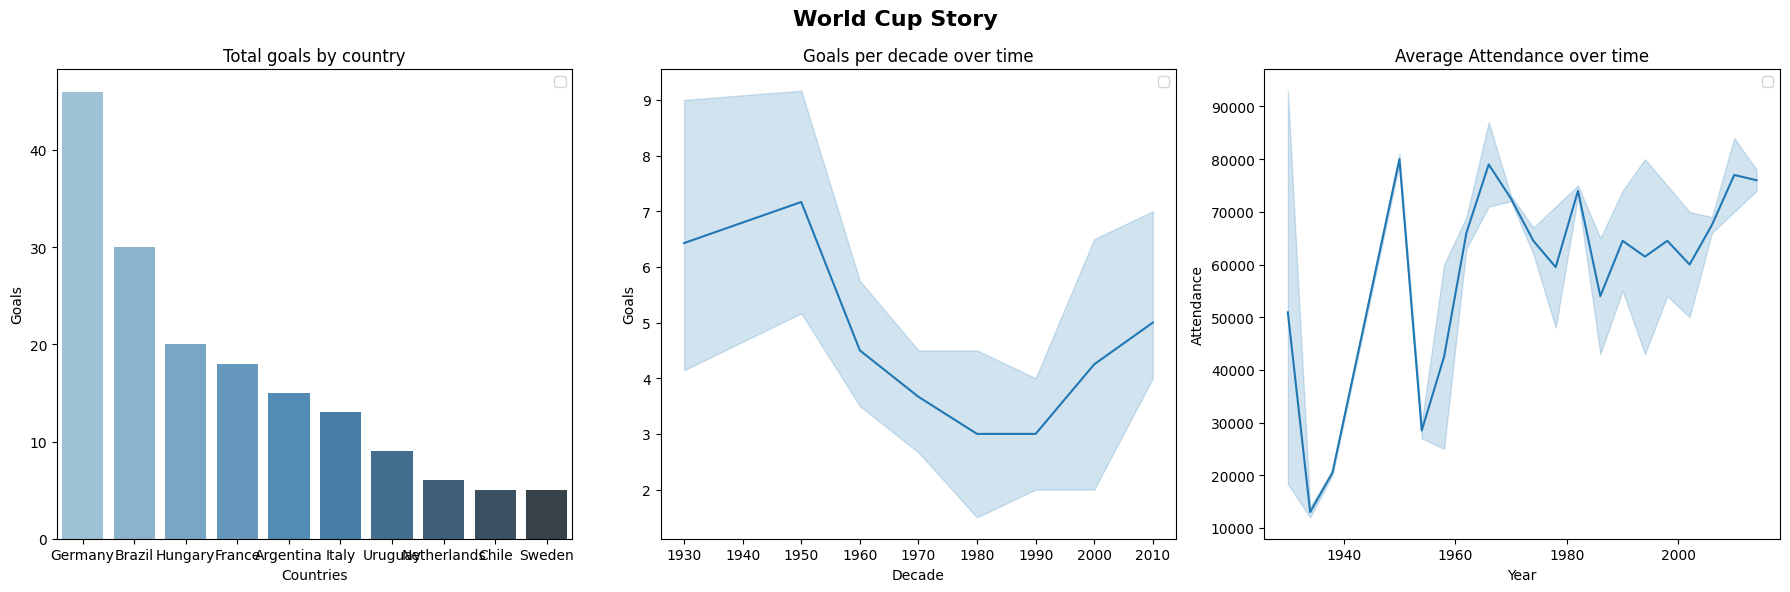

In [33]:
# 1. Total goals by country (Q1 result) as a bar chart
# 2. Goals per decade over time as a line chart
# 3. Attendance over the years as a line chart

import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(1,3, figsize=(18,6))
fig.suptitle('World Cup Story', fontsize=16, fontweight='bold')

#1
sns.barplot(x=total_goals.index, y=total_goals.values, palette='Blues_d', ax=axs[0])
axs[0].set_title('Total goals by country')
axs[0].set_ylabel('Goals')
axs[0].set_xlabel('Countries')
axs[0].legend()

#2
sns.lineplot(data=df, x='Decade', y='TotalGoals', ax=axs[1])
axs[1].set_title('Goals per decade over time')
axs[1].set_ylabel('Goals')
axs[1].legend()

#3
sns.lineplot(data=df, x='Year', y='Attendance', estimator='mean', ax=axs[2])
axs[2].set_title('Average Attendance over time')
axs[2].set_ylabel('Attendance')
axs[2].legend()


plt.tight_layout()
plt.savefig('worldcup_story.png', dpi=150, bbox_inches='tight')
plt.show()